In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from scipy.linalg import circulant
from torch.autograd import Variable

from util.DataGen import nai_pulse
from util.Processing import td_convolve, td_nnlsr_deconvolve
from util.Plotting import plot_photons

In [9]:
device = torch.device("cuda")

[167 232 246 108 145 175 225 168 187 223 236 194 127 248 219]
(15,) (15,)
(15,) (352,) (352,)
856 857.9485767947598


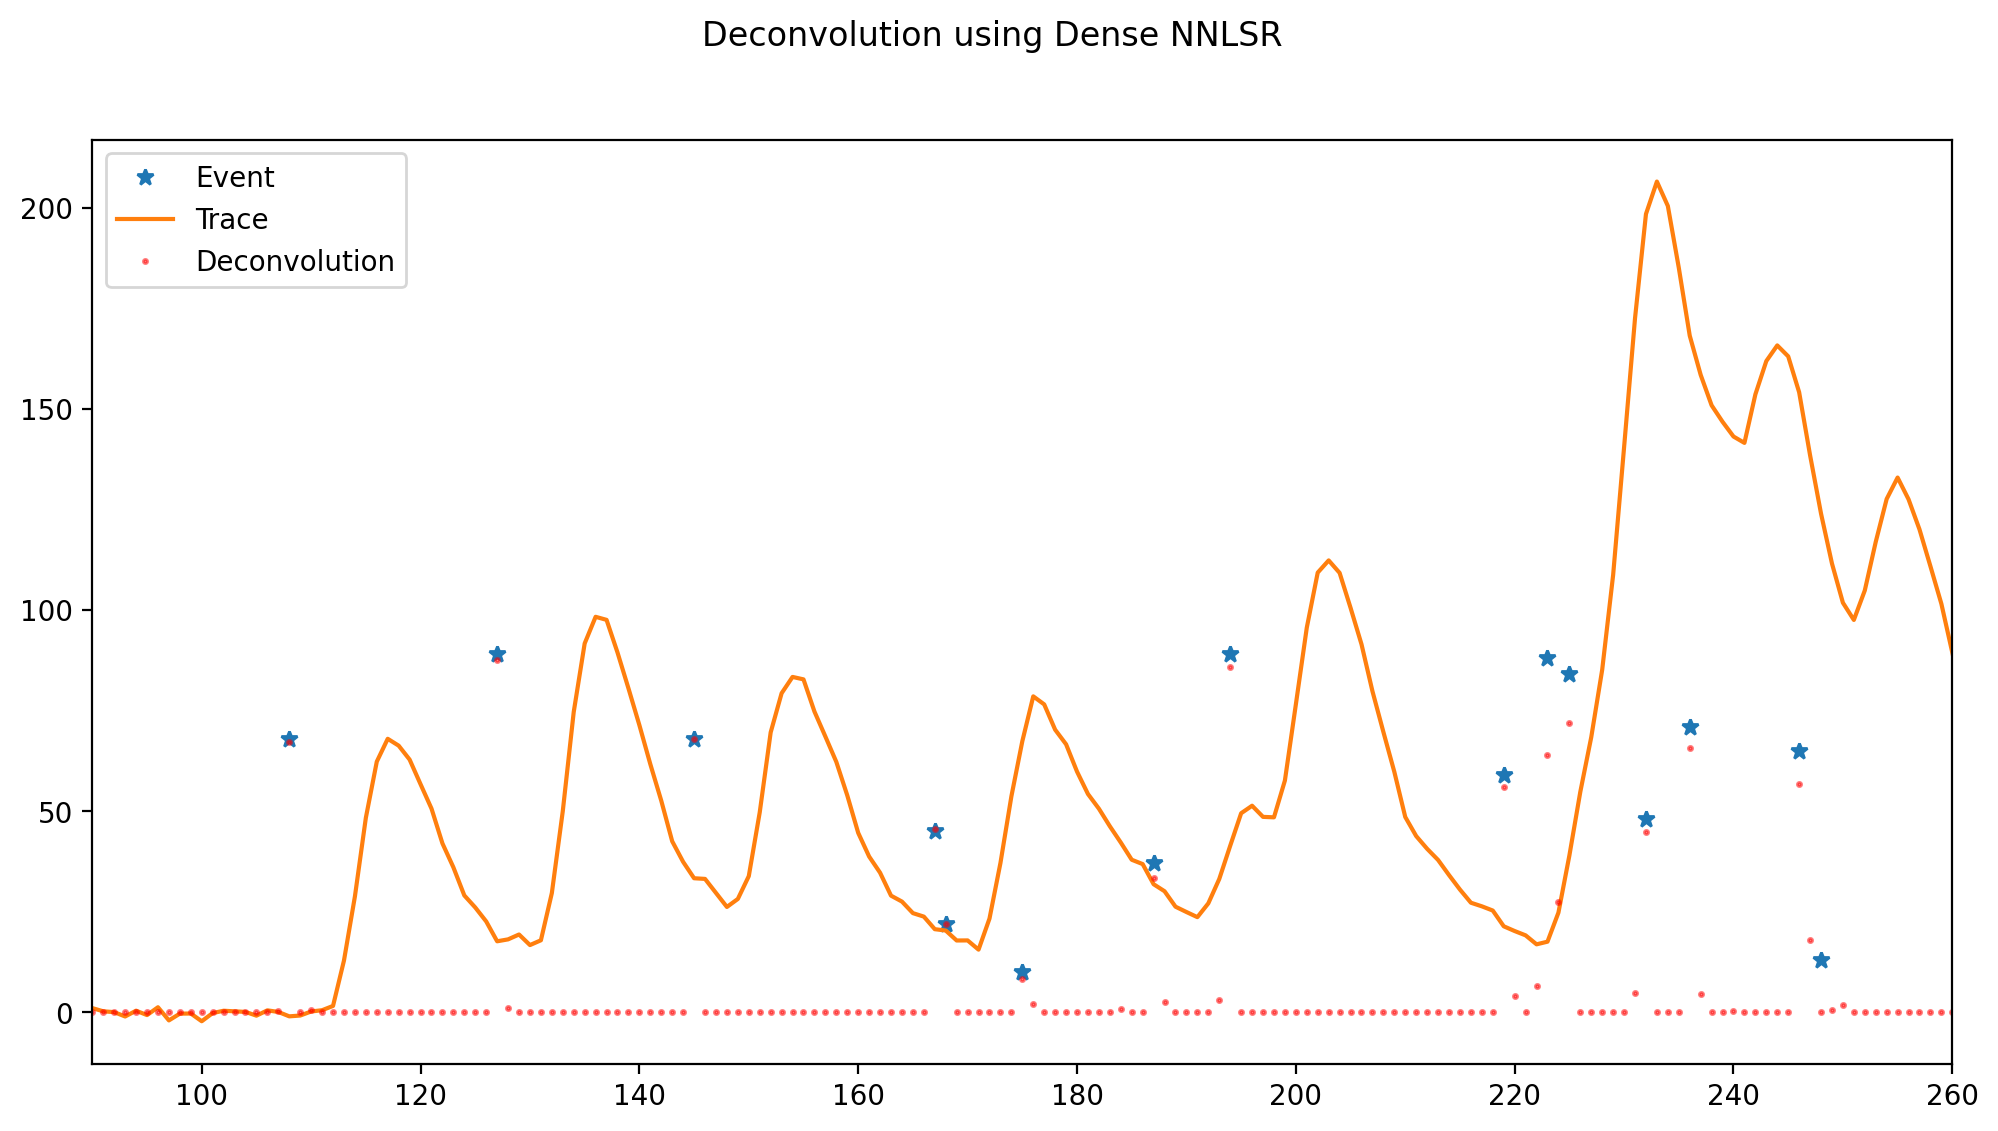

In [10]:
# Construct Trace
np.random.seed(0)

n_trace = 150
n_photons = 15
noise_std = 1
_, kernel = nai_pulse(1)


energy_list = np.random.randint(1, 100, n_photons)
indeces = np.random.choice(np.arange(n_trace), size=n_photons, replace=False) + kernel.size
print(indeces)
print(energy_list.shape, indeces.shape)
energy_trace = np.zeros(n_trace + 2 * kernel.size)
energy_trace[indeces] = energy_list

trace = td_convolve(x=energy_trace, kernel=kernel)
trace += np.random.normal(size=trace.size, scale=noise_std)

deconvolved = td_nnlsr_deconvolve(y=trace, kernel=kernel)

print(energy_list.shape, energy_trace.shape, trace.shape)

fig, axes = plt.subplots(1, 1, figsize=(12, 6), dpi=200)
w = energy_trace > 0
axes.plot(np.arange(energy_trace.size)[w], energy_trace[w], label='Event', marker='*', linestyle='')
axes.plot(trace, label='Trace')
axes.plot(deconvolved, label='Deconvolution', alpha=.5, marker='.', markersize=3, linestyle='', color='red')
axes.set_xlim(90,260)

fig.suptitle('Deconvolution using Dense NNLSR')
axes.legend()

print(np.sum(energy_list), np.sum(deconvolved))

101 352


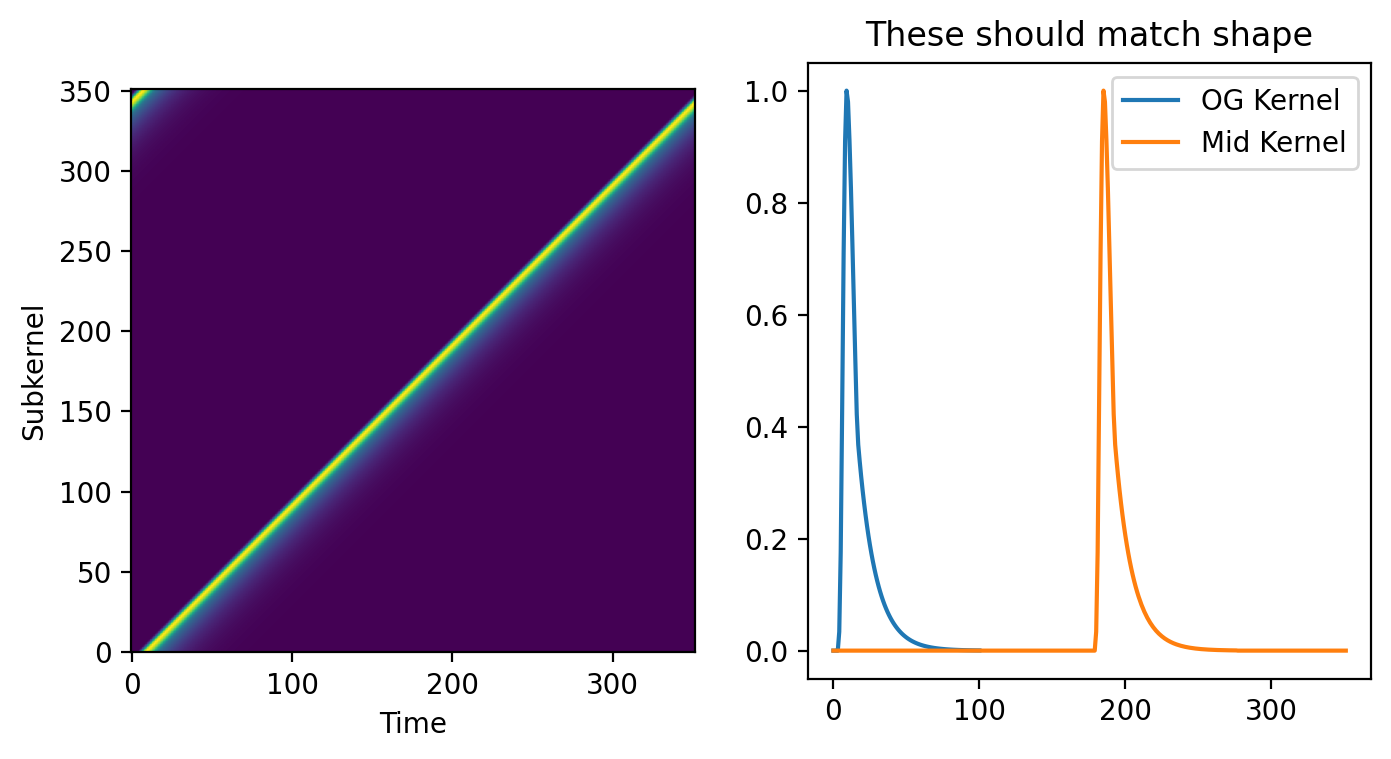

In [11]:
def dense_double_padded_circulant(kernel, size, show=False):
    # Produces C of shape [Time, channels]. Unforunately, Time=channels
    # so plotting is used to double-check they are correct...
    
    assert size > kernel.size
    print(kernel.size, size)
    # Square matrix
    # assuming it is to be used with double padded trace
    C_ = circulant(np.concatenate((kernel, np.zeros(size - kernel.size))))
    
    # Zero the padded regions
    # DO NOT USE
    # C_[:kernel.size, :] = 0
    # C_[size - kernel.size:, :] = 0
    
    # USE
    # C_[:, :kernel.size] = 0
    # C_[:, size - kernel.size:] = 0
    
    if show:
        fig, axes = plt.subplots(1,2,figsize=(8,4), dpi=200)
        axes[0].imshow(C_.T, origin='lower') 
        axes[0].set_xlabel('Time')
        axes[0].set_ylabel('Subkernel')
        
        axes[1].plot(kernel, label='OG Kernel')
        # needs to be [time, kernel n]
        axes[1].plot(C_[:, C_.shape[1]//2], label='Mid Kernel') # all time for middle kernel
        axes[1].set_title('These should match shape')
        axes[1].legend()
    
    return C_

C_numpy = dense_double_padded_circulant(kernel, energy_trace.size, show=True)
print()
    

In [12]:
# # Y=CX. Y:Trace, X, deconv. 
# # Y' = CX'
# # Loss = Y - Y'
# 
# Y = Variable(torch.tensor(trace), requires_grad=True).to(device)
# X = Variable(torch.ones_like(Y), requires_grad=True).to(device)
# C = Variable(torch.tensor(C_numpy), requires_grad=True).to(device)
# # C = Variable(torch.tensor(dense_double_padded_circulant(kernel=kernel[::-1], size=Y.shape[0], show=True)),
# #              requires_grad=True).to(device) # no...
# print(Y.shape, X.shape, C.shape)
# 
# losses = []
# neg_regs = []
# magnitude = []
# 
# fig, axes = plt.subplots(3,1, figsize=(8,6), dpi=200)
# axes[0].plot(np.arange(energy_trace.size)[w], energy_trace[w], label='Event', marker='*', linestyle='')
# axes[0].plot(Y.cpu().detach().numpy(), label='Y')
# 
# event = np.where(energy_trace)
# print(event)
# 
# # Hyperparameters
# lr = .0001
# neg_alpha = 1E4
# l1_alpha = 2E1
# 
# n = 1000
# for i in range(n):
#     with torch.enable_grad():
#         if (i) % (n//5) == 0:
#             # plt.plot(X.cpu().detach().numpy(), label='$X_{}$'.format(i))
# 
#             X_d = X.cpu().detach().numpy()
#             magnitude.append(X_d[event])
#             axes[0].plot(X_d)
#         # plt.plot(X.detach().numpy(), label='X{}'.format(i))
# 
#         # This shows C is correct...
#         # x2 = C @ torch.tensor(energy_trace)
#         # plt.plot(x2.cpu().detach().numpy(), marker='.', linestyle='', markersize=2, label='X2', color='red')
# 
#         X.retain_grad()
#         Yp = C @ X # [Time, Kernel_n] @ [Sparse Time]
# 
#         # TODO try huber loss
# 
#         residual = (Y - Yp)**2      
#         sum_R = torch.sum(residual)
#         loss = sum_R.detach().item()
#         losses.append(loss)
# 
#         # Strongly penalize negativity
#         neg_reg = - neg_alpha * torch.sum(Yp[Yp < 0])
#         neg_reg_val = neg_reg.detach().item()
#         neg_regs.append(neg_reg_val)
# 
#         # Penalize density
# 
#         # L1 Loss
#         loss += l1_alpha * torch.mean(residual)
# 
#         # Backpropogate
#         loss += neg_reg
#         loss.backward()
# 
#         # print(X.grad)
#         # TODO could try an optimizer...
#         X = X - lr * X.grad
# 
#     # print(losses)
# 
# axes[0].legend()
# 
# axes[1].plot(losses, label='Loss')
# axes[1].plot(neg_regs, label='Neg Reg')
# axes[1].legend()
# # axes[1].set_yscale('log')
# 
# axes[2].plot(magnitude, label='Est. mag. at event')
# axes[2].legend()
# 
# print(np.sum(energy_trace), np.sum(energy_trace) * np.sum(kernel), np.sum(X.cpu().detach().numpy()))

In [13]:
# x = torch.ones(5)  # input tensor
# y = torch.zeros(3)  # expected output
# w = torch.randn(5, 3, requires_grad=True)
# b = torch.randn(3, requires_grad=True)
# z = x @ w + b
# loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)
# 
# loss.backward()
# print(w.grad)
# print(b.grad)

In [ ]:
# Y=CX. Y:Trace, X, deconv. 
# Y' = CX'
# Loss = Y - Y'

Y = Variable(torch.tensor(trace), requires_grad=True).to(device)
X = Variable(.05 * torch.ones_like(Y), requires_grad=True).to(device)
C = Variable(torch.tensor(C_numpy), requires_grad=True).to(device)

losses = []
main_losses = []
l1_losses = []

trace_over_time = []
magnitudes = []

event = np.where(energy_trace)

# Hyperparameters
# SGD Optimizer: Note iter=5E6 and  lr=1E-3 getting very close to correct solution
# ADAM is light-years better than SGD...

iterations = 1E5
lr = 1E-3 # 1E-3 is a hard upper limit on LR while converging to solutions
l1_alpha = 0 #1E-5 # might be good to define this on a log scale? density relative to n observations in trace

# optimizer = torch.optim.SGD([X], lr=lr)
optimizer = torch.optim.Adam([X], lr=lr)

plot_n = 10
printn = 100
for i in range(int(iterations)):
        
    if (i) % (iterations//plot_n) == 0:
        X_d = X.cpu().detach().numpy()
        magnitudes.append(X_d[event])
        trace_over_time.append((i, X_d))
        
    Yp = C @ torch.exp(X)
    residual = Yp - Y
    
    # MSE Loss
    main_loss = torch.mean((residual)**2) # MSE
    
    # # Huber loss
    # delta = 1
    # gt_delta = torch.abs(residual) > delta
    # lte_delta = torch.abs(residual) <= delta
    # main_loss = .5 * torch.sum((residual[lte_delta])**2)/torch.sum(lte_delta) +\
    #             torch.sum(delta*(torch.abs(residual[gt_delta]) - .5*delta))/torch.sum(gt_delta)
    
    loss = main_loss
    main_losses.append(main_loss.detach().item())

    # Penalize density
    # TODO try loss += sum(alpha_t * sigmoid(beta_t * weights)) alpha or beta better? Both?
    # L1 Loss
    l1_loss = l1_alpha * torch.mean(torch.abs(X))
    loss += l1_loss
    l1_losses.append(l1_loss.detach().item())

    # Backpropogate
    losses.append(loss.detach().item())
    loss.backward(retain_graph=True)
    optimizer.step()
    optimizer.zero_grad()
    
    if (i) % (iterations//printn) == 0:
        # print(i, loss.detach().cpu().item(), l1_loss.detach().cpu().item())
        print(i, loss.detach().cpu().item())

In [ ]:
x_plot = np.exp(X.detach().cpu())
y_plot = Y.cpu().detach().numpy()

fig, axes = plt.subplots(3,1, figsize=(10,10), dpi=200)
axes[0].plot(np.arange(energy_trace.size), energy_trace, color='b', marker='.', linestyle='', markersize=5)
axes[0].plot(np.arange(energy_trace.size)[w], energy_trace[w], color='b', label='Events', marker='*', linestyle='', markersize=10)
axes[0].plot(y_plot, label='Y', color='orange')

axes[0].plot(x_plot, color='red',  label='Final Weights', marker='.', markersize=5, linestyle='')
# axes[0].plot((C.detach().cpu() @ x_plot, label='Trace Recon.', linestyle='--')
# axes[0].plot((C.detach().cpu().numpy()) @ energy_trace, label='Event Trace Recon.', linestyle='--')
axes[0].legend()
# axes[0].set_xlim(90,260)

axes[1].plot(main_losses, '.', label='Main Loss', alpha=1)
axes[1].plot(l1_losses, '.', label='L1 Loss', alpha=1)
axes[1].plot(losses, label='Total Loss')
axes[1].legend()
# axes[1].set_xlim(10000,10500)
axes[1].set_yscale('log')
for tup in trace_over_time:
    i, trace_est = tup
    axes[2].plot(np.exp(trace_est), label=i)
axes[2].legend()

In [ ]:
"""

Expectation (% error) based on response matrices? What bounds do the response matrices put on our detection acc due to probabilistic effects...?
- Can sampling to estimate TGF spectrum and reponse matrix simultaneously help by using TGF spectrum as a prior?
- TGF Spectrum prior -> Trace event energy estimations -> sum for TGF Prior 

Another idea tha might be interesting is to LPF real signals if there is variance in the reponse kernels. Perhaps this would help with subtle variation in the kernels...

Countrate vs optimal conv-sum values

"""
